# Determinants of Heating Load in Residential Building Design
**Name**:  Jerik Adrian Valencia BAYON

**Student Number**:  6530363577

___
## Overview

### Purpose:

* The purpose of this Final Project is to determine which residential building design factors contribute to heating load.
* The key **dependent variable** (DV) is heating load.
* Key **independent variables** (IVs) include:
    * relative compactness
    * surface area
    * wall area
    * roof area
    * overall height
    * orientation
    * glazing area
    * glazing area distribution
* This dataset contains 768 cases (i.e., 768 different simulated residential building designs).

### Dataset source:

* The data come from the [energy efficiency](https://archive.ics.uci.edu/dataset/242/energy+efficiency) dataset from the [UCI Machine Learning repository](https://archive.ics.uci.edu/ml/index.php):
* The data are available for download [here](https://archive.ics.uci.edu/dataset/242/energy+efficiency).
* Analyses of this dataset have been published previously in Tsanas et al. (2012).

#### References:

A. Tsanas, and A. Xifara (2012). Accurate quantitative estimation of energy performance of residential buildings
using statistical machine learning tools. Energy and Buildings, Elsevier, 49:560-567.
doi: https://doi.org/10.1016/j.enbuild.2012.03.003

___

## Descriptive Statistics

First we check ranges and variation to see which inputs actually change and could influence heating load.

In [1]:
%%capture
%run parse_data.py
%run -i descriptive.py

In [2]:
display_dispersion_table(num=1)

<br><br><p><span style="font-size: 1.2em;"><b>Table 1</b>: Dispersion summary statistics</span></p>

,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_distribution,heating_load
st.dev.,0.1057,88.0,43.6,45.1,1.75,1.1,0.13,1.5,10.08
min,0.6200,514.5,245.0,110.2,3.50,2.0,0.00,0.0,6.01
max,0.9800,808.5,416.5,220.5,7.00,5.0,0.40,5.0,43.10
range,0.3600,294.0,171.5,110.2,3.50,3.0,0.40,5.0,37.09
25th,0.6825,606.4,294.0,140.9,3.50,2.8,0.10,1.8,12.99
75th,0.8300,741.1,343.0,220.5,7.00,4.2,0.40,4.0,31.67
IQR,0.1475,134.8,49.0,79.6,3.50,1.5,0.30,2.2,18.68


Results from Table 1 shows:

* Heating load varies a lot (wide range), so it’s meaningful to model.
* Geometry variables (surface/wall/roof areas) have large spreads → they could strongly affect heating load.
* Overall height only takes two values (3.5 and 7.0) → suggests heating load may form two clusters.
* Glazing area distribution ranges 0–5, and 0 is special (no glazing / no distribution).

Then we look at simple relationships (scatter plots/correlations for continuous variables; boxplots for categories) to spot strong patterns worth testing formally, and weak patterns that might not matter.

<p><span style="font-size: 1.2em;"><b>Figure 1</b>: Descriptive plots</span></p><br><br>

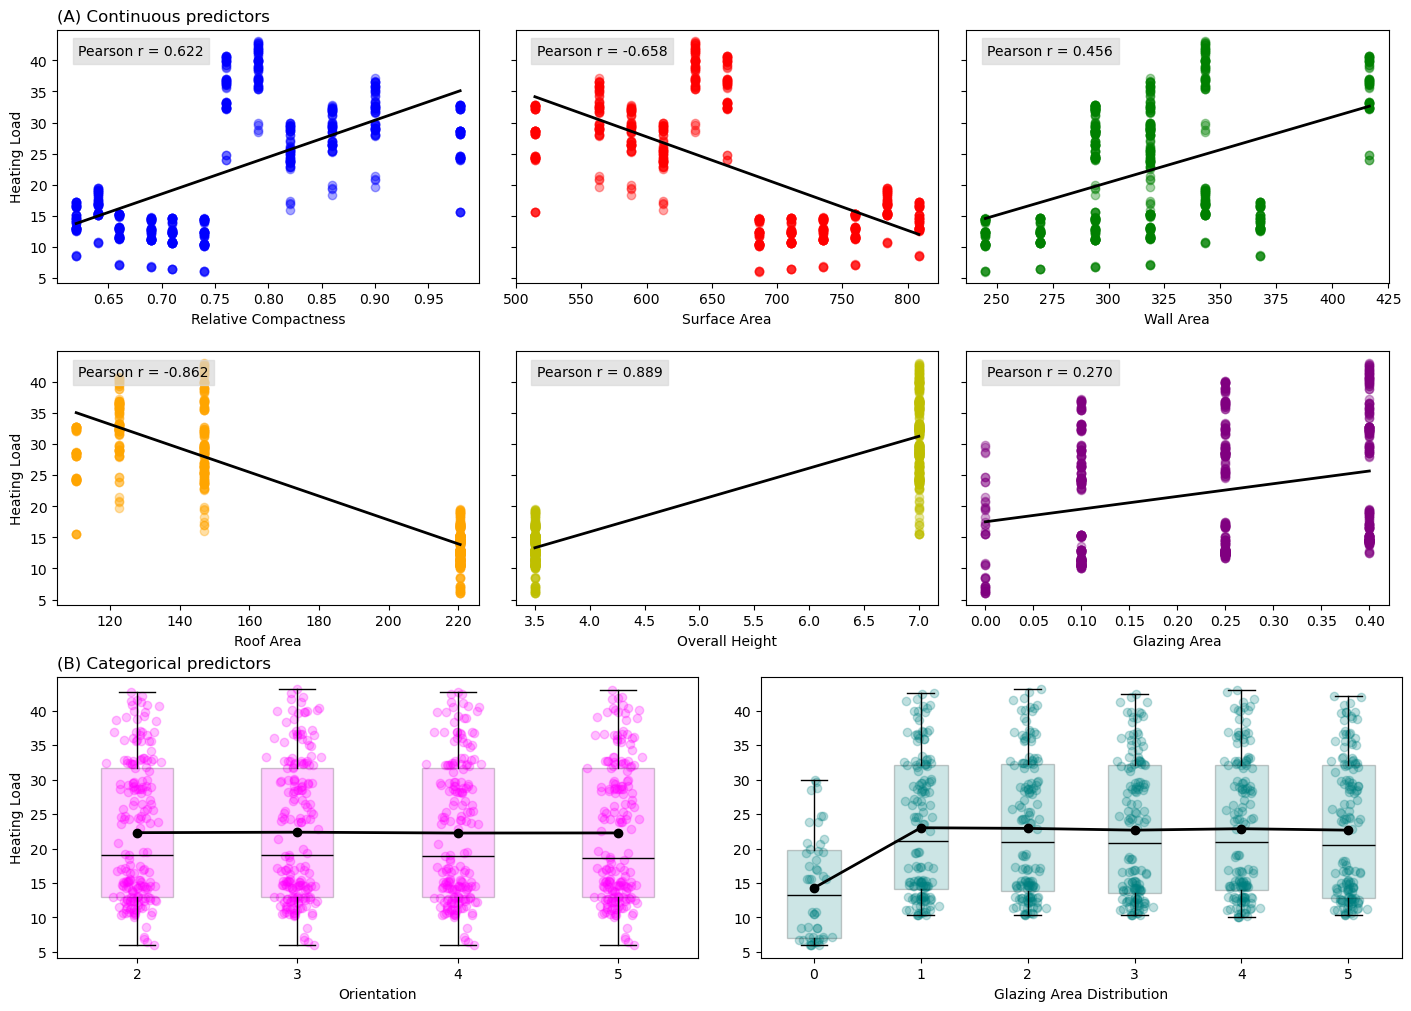

In [3]:
plot_descriptive(num=1)

Results from Figure 1 shows:

* Strong positive or negative associations appear for several geometry variables.
* The mean line for Orientation is almost flat and the boxplots overlap a lot → suggests little orientation effect.
* For Glazing Area Distribution, category 0 sits much lower than 1–5, while categories 1–5 look similar → suggests comparing 0 vs non-0 is meaningful.

___

## Hypothesis Testing

Descriptive statistics suggest specific unique traits:

* Height has only two levels (3.5 vs 7.0) → perfect for a t-test.
* Glazing distribution has a special 0 vs non-0 structure → perfect for a t-test, plus ANOVA across all 0–5 categories.
* Orientation has 4 categories that show similar heating load mean → appropriate for one-way ANOVA.

<p><span style="font-size: 1.2em;"><b>Figure 2</b>: Glazing distribution effects on heating load (one-way ANOVA across categories, plus Welch t-test for 0 vs non-0)</span></p><br><br>

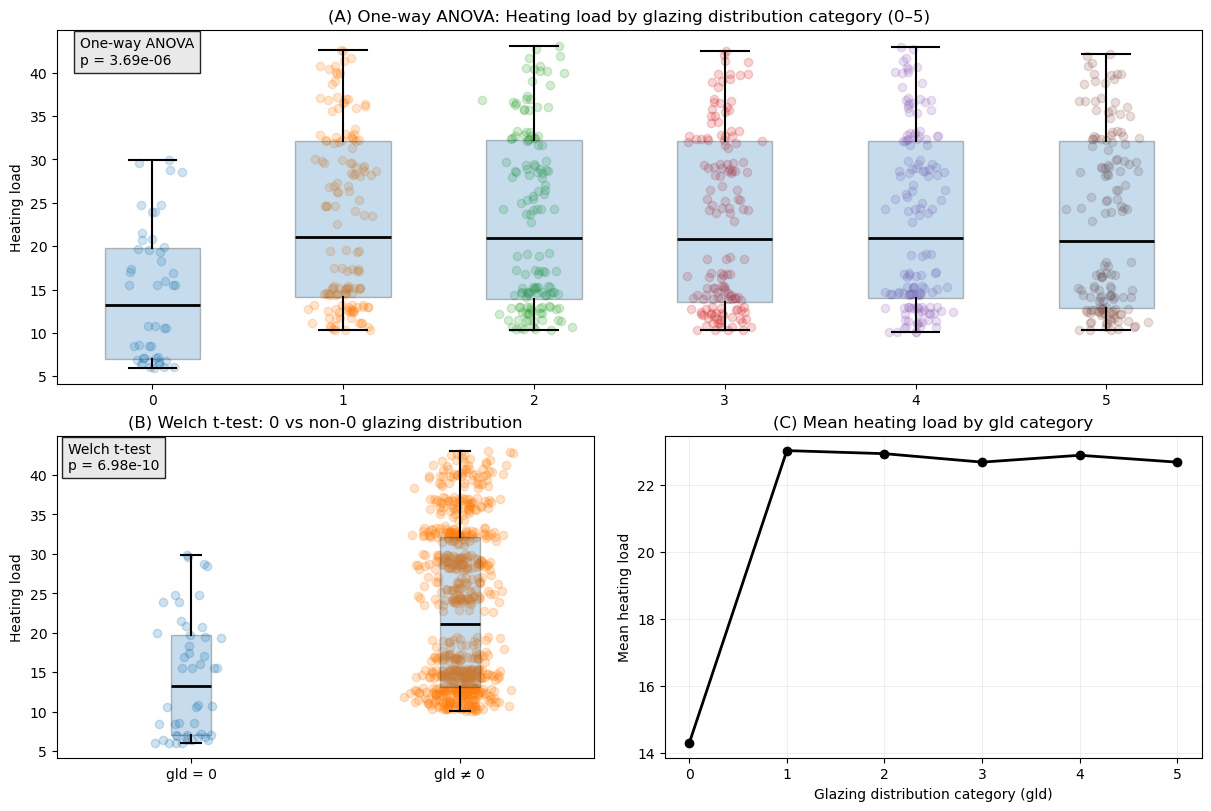

In [4]:
%run -i classical.py
plot_hypothesis1(num=2)

Results from Figure 2 shows:

**Panel A**
* Very small p-value → heating load differs across glazing distribution categories overall.
* Visual pattern shows that category 0 is the outlier (lower heating load), while 1–5 are similar.

**Panel B**
* Very small p-value → strong evidence that “no glazing distribution” vs “some glazing distribution” differs in mean heating load.

**Panel C**
* The mean line jumps from 0 → 1, then becomes almost flat from 1 → 5.
* This supports the idea that the main effect is presence vs absence, not which non-zero category.

<p><span style="font-size: 1.2em;"><b>Figure 3</b>: Orientation and height effects on heating load (one-way ANOVA for orientation, plus Welch t-test for height groups)</span></p><br><br>

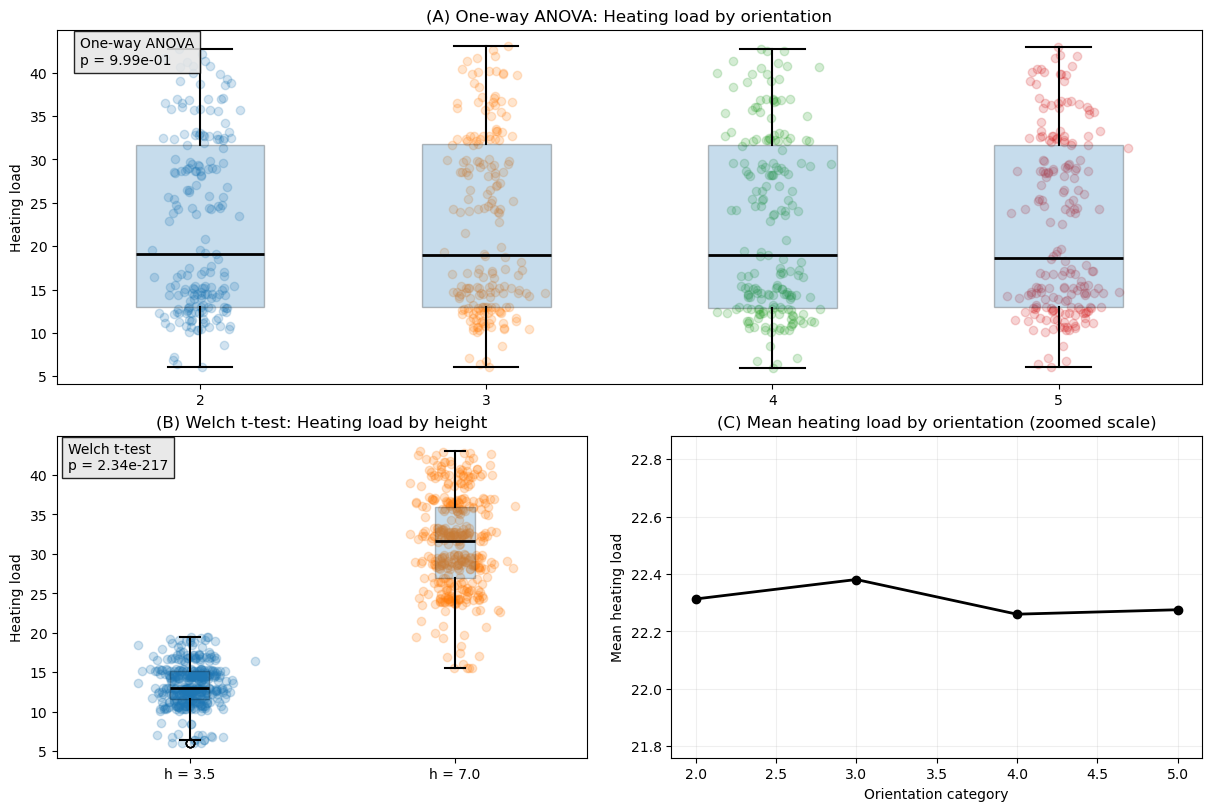

In [5]:
plot_hypothesis2(num=3)

Results from Figure 3 shows:

**Panel A**
* p-value ~ 1 (very large) → no evidence that heating load differs by orientation group.
* Visual overlap of boxes supports this.

**Panel B**
* Extremely tiny p-value → heating load is dramatically different between the two height groups.
* Boxplots show strong separation (two clusters).

**Panel C**
* Mean heating load across orientations changes only slightly → consistent with previous results.

___

## Machine Learning

After identifying which factors matter, the predictive performance was tested using KNN Regression and SVR Regression. Validation was done using held-out test set evaluation. The model was trained on training data, and then reported metrics on unseen test data (R², RMSE, MAE). The R², RMSE, MAE show performance on unseen data. The residual plots show whether the performance is trustworthy across the full range.

In [6]:
%run -i machine.py

<p><span style="font-size: 1.2em;"><b>Figure 4</b>: Machine learning regression with validation — Observed vs predicted on the held-out test set (KNN vs SVR)</span></p><br><br>

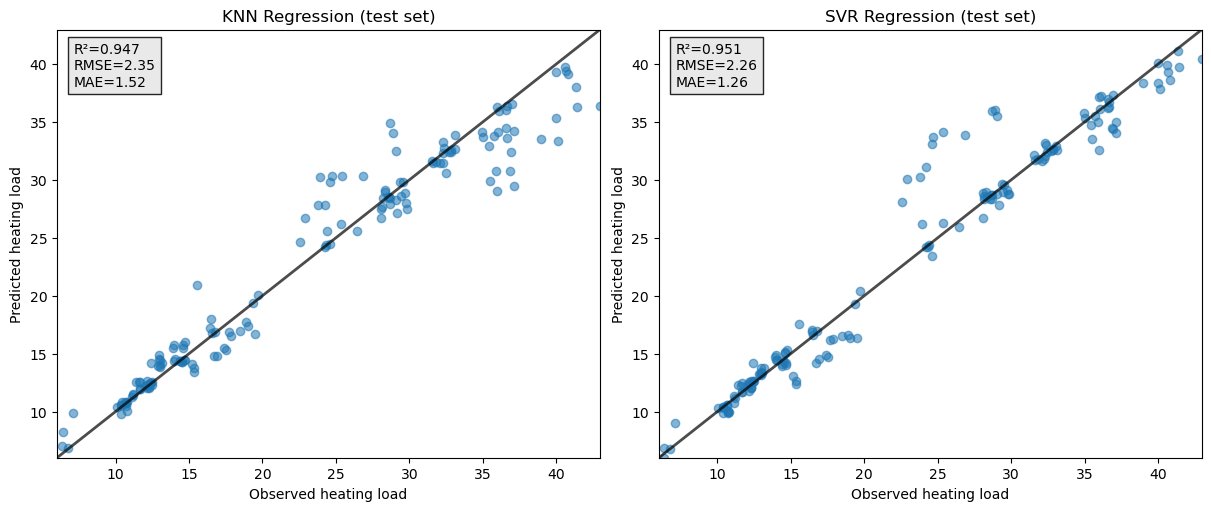

In [7]:
plot_ml_figure1(num=4)

Results from Figure 4 show:
 
* Both KNN and SVR points lie close to the 45° line → good predictive accuracy.
* Both models generalize well but SVR is slightly better based on higher R<sup>2</sup>, and lower RMSE and MAE.

<p><span style="font-size: 1.2em;"><b>Figure 5</b>: Machine learning regression with validation — Residual diagnostics on the held-out test set (KNN vs SVR)</span></p><br><br>

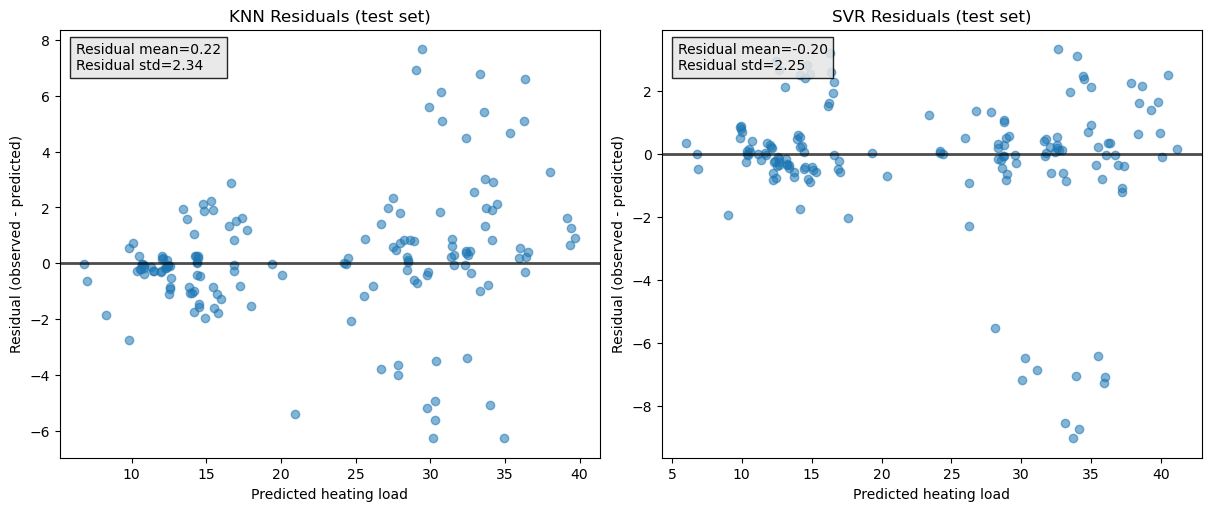

In [8]:
plot_ml_figure2(num=5)

Results from Figure 5 shows:

* Residuals are centered near 0 → little overall bias (good).
* Larger residuals at some higher predicted loads suggests “harder region” to predict (possible nonlinearity or interactions).
* SVR residuals look tighter overall in your plot → consistent with the slightly better metrics.